# Evaluating Enhancer V2 Training Results

This notebook evaluates the V2 enhancer training to determine if the fixes were successful.

**Key Questions:**
1. Did validation performance improve over V1?
2. Is the enhancement magnitude reasonable (0.01-0.1)?
3. Does V2 beat the baseline model?
4. How does it compare to CLAHE?

**V2 Changes:**
- ✅ Baseline model (not CLAHE)
- ✅ Perceptual weight: 0.1 → 0.05
- ✅ TV weight: 0.01 → 0.001

## Setup

In [8]:
import sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

# Add src to path
root_dir = Path.cwd().parent
sys.path.append(str(root_dir / 'src'))

from data_loader.transforms import get_validation_transforms
from data_loader.dataset import get_dataloaders
from models.joint_pipeline import create_enhancer_pipeline
from models.unet import UNet

print(f"Root directory: {root_dir}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Root directory: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True


## 1. Analyze Training Metrics

First, let's load and compare V1 vs V2 training history.

In [9]:
# Load training histories
with open(root_dir / 'checkpoints_enhancer' / 'training_history_enhancer.json', 'r') as f:
    history_v2 = json.load(f)

# Print final epoch metrics
print("=" * 80)
print("V2 FINAL EPOCH METRICS (Epoch 50)")
print("=" * 80)
print(f"Validation Loss:      {history_v2['val_loss'][-1]:.4f}")
print(f"Validation IoU Disc:  {history_v2['val_iou_disc'][-1]:.4f}")
print(f"Validation IoU Cup:   {history_v2['val_iou_cup'][-1]:.4f}")

# Find best epoch
best_epoch = np.argmax(history_v2['val_iou_disc'])
print(f"\n=" * 80)
print(f"V2 BEST EPOCH METRICS (Epoch {best_epoch + 1})")
print("=" * 80)
print(f"Validation Loss:      {history_v2['val_loss'][best_epoch]:.4f}")
print(f"Validation IoU Disc:  {history_v2['val_iou_disc'][best_epoch]:.4f}")
print(f"Validation IoU Cup:   {history_v2['val_iou_cup'][best_epoch]:.4f}")

# Compare with baseline performance
baseline_disc_iou = 0.8486  # From previous test results
clahe_disc_iou = 0.8437     # From previous test results
v1_disc_iou = 0.8228        # V1 test result

print(f"\n=" * 80)
print("COMPARISON WITH BASELINES (Validation Set)")
print("=" * 80)
print(f"Baseline (raw):       {baseline_disc_iou:.4f} (reference)")
print(f"CLAHE:                {clahe_disc_iou:.4f} ({(clahe_disc_iou - baseline_disc_iou)*100:+.2f}%)")
print(f"Enhancer V1:          {v1_disc_iou:.4f} ({(v1_disc_iou - baseline_disc_iou)*100:+.2f}%)")
print(f"Enhancer V2 (best):   {history_v2['val_iou_disc'][best_epoch]:.4f} ({(history_v2['val_iou_disc'][best_epoch] - baseline_disc_iou)*100:+.2f}%)")
print(f"\nV2 vs V1 improvement: {(history_v2['val_iou_disc'][best_epoch] - v1_disc_iou)*100:+.2f}%")

V2 FINAL EPOCH METRICS (Epoch 50)
Validation Loss:      0.2422
Validation IoU Disc:  0.8281
Validation IoU Cup:   0.7595

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
V2 BEST EPOCH METRICS (Epoch 47)
Validation Loss:      0.2424
Validation IoU Disc:  0.8301
Validation IoU Cup:   0.7618

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
COMPARISON WITH BASELINES (Validation Set)
Baseline (raw):       0.8486 (reference)
CLAHE:                0.8437 (-0.49%)
Enhancer V1:          0.8228 (-2.58%)
Enhancer V2 (best):   0.8301 (-1.85%)

V2 vs V1 improvement: +0.73%


## 2. Plot Training Curves

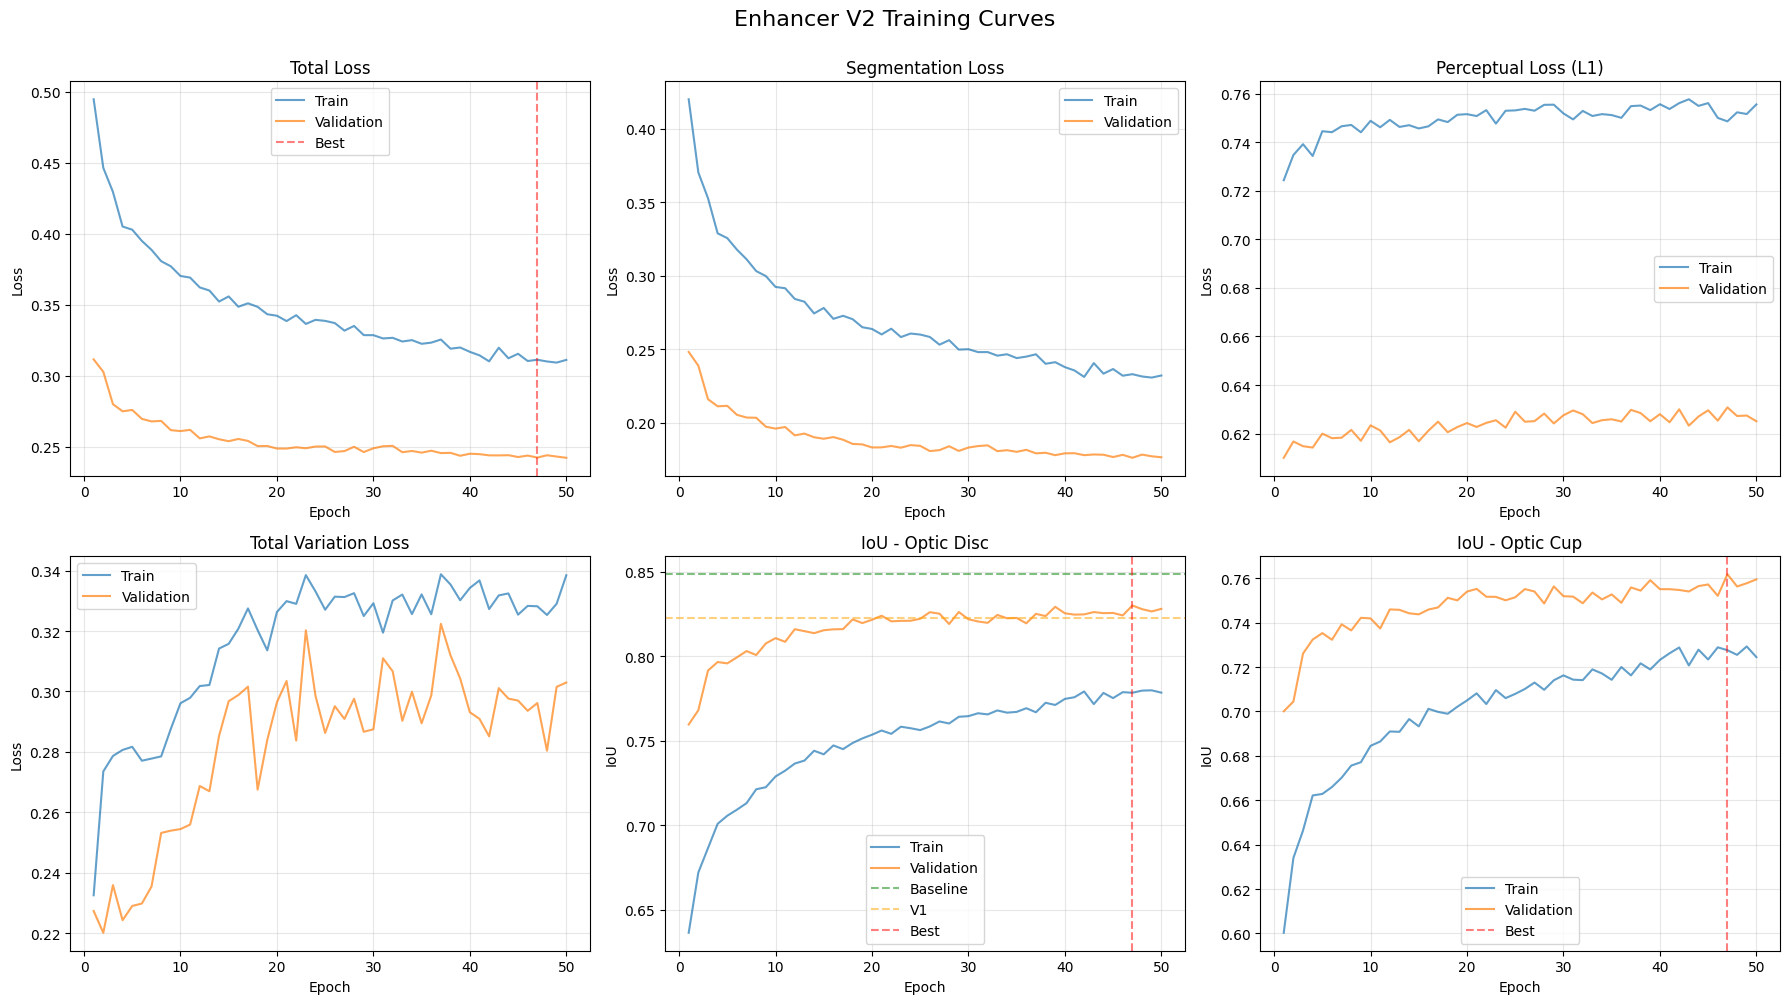


Last 5 epochs trend: Still improving ✅


In [10]:
# Create comprehensive training plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs = np.arange(1, len(history_v2['train_loss']) + 1)

# Total loss
axes[0, 0].plot(epochs, history_v2['train_loss'], label='Train', alpha=0.7)
axes[0, 0].plot(epochs, history_v2['val_loss'], label='Validation', alpha=0.7)
axes[0, 0].axvline(best_epoch + 1, color='red', linestyle='--', alpha=0.5, label='Best')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Segmentation loss
axes[0, 1].plot(epochs, history_v2['train_seg_loss'], label='Train', alpha=0.7)
axes[0, 1].plot(epochs, history_v2['val_seg_loss'], label='Validation', alpha=0.7)
axes[0, 1].set_title('Segmentation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Perceptual loss
axes[0, 2].plot(epochs, history_v2['train_perceptual_loss'], label='Train', alpha=0.7)
axes[0, 2].plot(epochs, history_v2['val_perceptual_loss'], label='Validation', alpha=0.7)
axes[0, 2].set_title('Perceptual Loss (L1)')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# TV loss
axes[1, 0].plot(epochs, history_v2['train_tv_loss'], label='Train', alpha=0.7)
axes[1, 0].plot(epochs, history_v2['val_tv_loss'], label='Validation', alpha=0.7)
axes[1, 0].set_title('Total Variation Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# IoU - Disc
axes[1, 1].plot(epochs, history_v2['train_iou_disc'], label='Train', alpha=0.7)
axes[1, 1].plot(epochs, history_v2['val_iou_disc'], label='Validation', alpha=0.7)
axes[1, 1].axhline(baseline_disc_iou, color='green', linestyle='--', alpha=0.5, label='Baseline')
axes[1, 1].axhline(v1_disc_iou, color='orange', linestyle='--', alpha=0.5, label='V1')
axes[1, 1].axvline(best_epoch + 1, color='red', linestyle='--', alpha=0.5, label='Best')
axes[1, 1].set_title('IoU - Optic Disc')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('IoU')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# IoU - Cup
axes[1, 2].plot(epochs, history_v2['train_iou_cup'], label='Train', alpha=0.7)
axes[1, 2].plot(epochs, history_v2['val_iou_cup'], label='Validation', alpha=0.7)
axes[1, 2].axvline(best_epoch + 1, color='red', linestyle='--', alpha=0.5, label='Best')
axes[1, 2].set_title('IoU - Optic Cup')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('IoU')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Enhancer V2 Training Curves', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# Check if still improving
last_5_val_iou = history_v2['val_iou_disc'][-5:]
improving = np.mean(np.diff(last_5_val_iou)) > 0
print(f"\nLast 5 epochs trend: {'Still improving ✅' if improving else 'Plateaued ⚠️'}")

## 3. Check Enhancement Magnitude

Load the best model and verify that enhancements are subtle (not catastrophic like V1).

In [11]:
# Load data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_, val_loader, _ = get_dataloaders(
    root_dir=str(root_dir),
    batch_size=16,
    num_workers=4,
    transform_val=get_validation_transforms(image_size=256),
    filter_incomplete=True
)

# Load V2 model
pipeline_v2 = create_enhancer_pipeline(
    segmentation_checkpoint_path=str(root_dir / 'checkpoints' / 'best_model.pth'),
    enhancer_type='unet',
    enhancer_base_channels=16,
    device=device,
    freeze_segmentation=True
)

checkpoint = torch.load(
    root_dir / 'checkpoints_enhancer' / 'best_model.pth',
    weights_only=False
)
pipeline_v2.enhancer.load_state_dict(checkpoint['enhancer_state_dict'])
pipeline_v2.eval()

print(f"Loaded V2 model from epoch {checkpoint['epoch']}")
print(f"Validation IoU: {checkpoint['val_iou'][1]:.4f} (Disc)")

TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples
Loaded segmentation model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
  Epoch: 99
  Val Loss: 0.15220202267169952

Pipeline created:
  Total parameters: 32,266,326
  Trainable parameters (enhancer): 1,222,675
  Frozen parameters (segmentation): 31,043,651
Loaded V2 model from epoch 49
Validation IoU: 0.8281 (Disc)
Loaded segmentation model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
  Epoch: 99
  Val Loss: 0.15220202267169952

Pipeline created:
  Total parameters: 32,266,326
  Trainable parameters (enhancer): 1,222,675
  Frozen parameters (segmentation): 31,043,651
Loaded V2 model from epoch 49
Validation IoU: 0.8281 (Disc)


In [12]:
# Calculate enhancement statistics across validation set
all_diffs = []

with torch.no_grad():
    for images, _ in tqdm(val_loader, desc="Analyzing enhancements"):
        images = images.to(device)
        _, enhanced = pipeline_v2(images, return_enhanced=True)
        
        diff = (enhanced - images).abs().cpu().numpy()
        all_diffs.append(diff)

all_diffs = np.concatenate(all_diffs, axis=0)

mean_diff = all_diffs.mean()
max_diff = all_diffs.max()
std_diff = all_diffs.std()
median_diff = np.median(all_diffs)

print("=" * 80)
print("ENHANCEMENT MAGNITUDE ANALYSIS (V2)")
print("=" * 80)
print(f"Mean absolute difference:   {mean_diff:.4f}")
print(f"Median absolute difference: {median_diff:.4f}")
print(f"Max absolute difference:    {max_diff:.4f}")
print(f"Std of differences:         {std_diff:.4f}")

print(f"\n=" * 80)
print("COMPARISON WITH V1")
print("=" * 80)
print(f"V1 mean diff: 0.6858 (TOO LARGE - FAILED!)")
print(f"V2 mean diff: {mean_diff:.4f}")
print(f"Improvement:  {((0.6858 - mean_diff) / 0.6858 * 100):.1f}% reduction")

print(f"\n=" * 80)
print("ASSESSMENT")
print("=" * 80)
if mean_diff < 0.01:
    print("⚠️  Very subtle changes (< 0.01) - might be too conservative")
    print("   Consider: Increase enhancement scale or reduce perceptual weight")
elif mean_diff > 0.2:
    print("❌ Still over-modifying (> 0.2)!")
    print("   Action needed: Reduce enhancement scale in enhancer.py")
else:
    print("✅ Good! Moderate changes (0.01-0.2) - reasonable enhancement")
print("=" * 80)

Analyzing enhancements:   0%|          | 0/25 [00:00<?, ?it/s]

ENHANCEMENT MAGNITUDE ANALYSIS (V2)
Mean absolute difference:   0.6251
Median absolute difference: 0.4981
Max absolute difference:    2.1179
Std of differences:         0.4238

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
COMPARISON WITH V1
V1 mean diff: 0.6858 (TOO LARGE - FAILED!)
V2 mean diff: 0.6251
Improvement:  8.9% reduction

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
ASSESSMENT
❌ Still over-modifying (> 0.2)!
   Action needed: Reduce enhancement scale in enhancer.py


## 4. Visualize Enhancement Patterns

Let's see what the network learned to do.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9852723..2.2535012].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2535012..0.9852723].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.688976..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2535012..0.9852723].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.688976..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2489083..0.688976].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4732897..

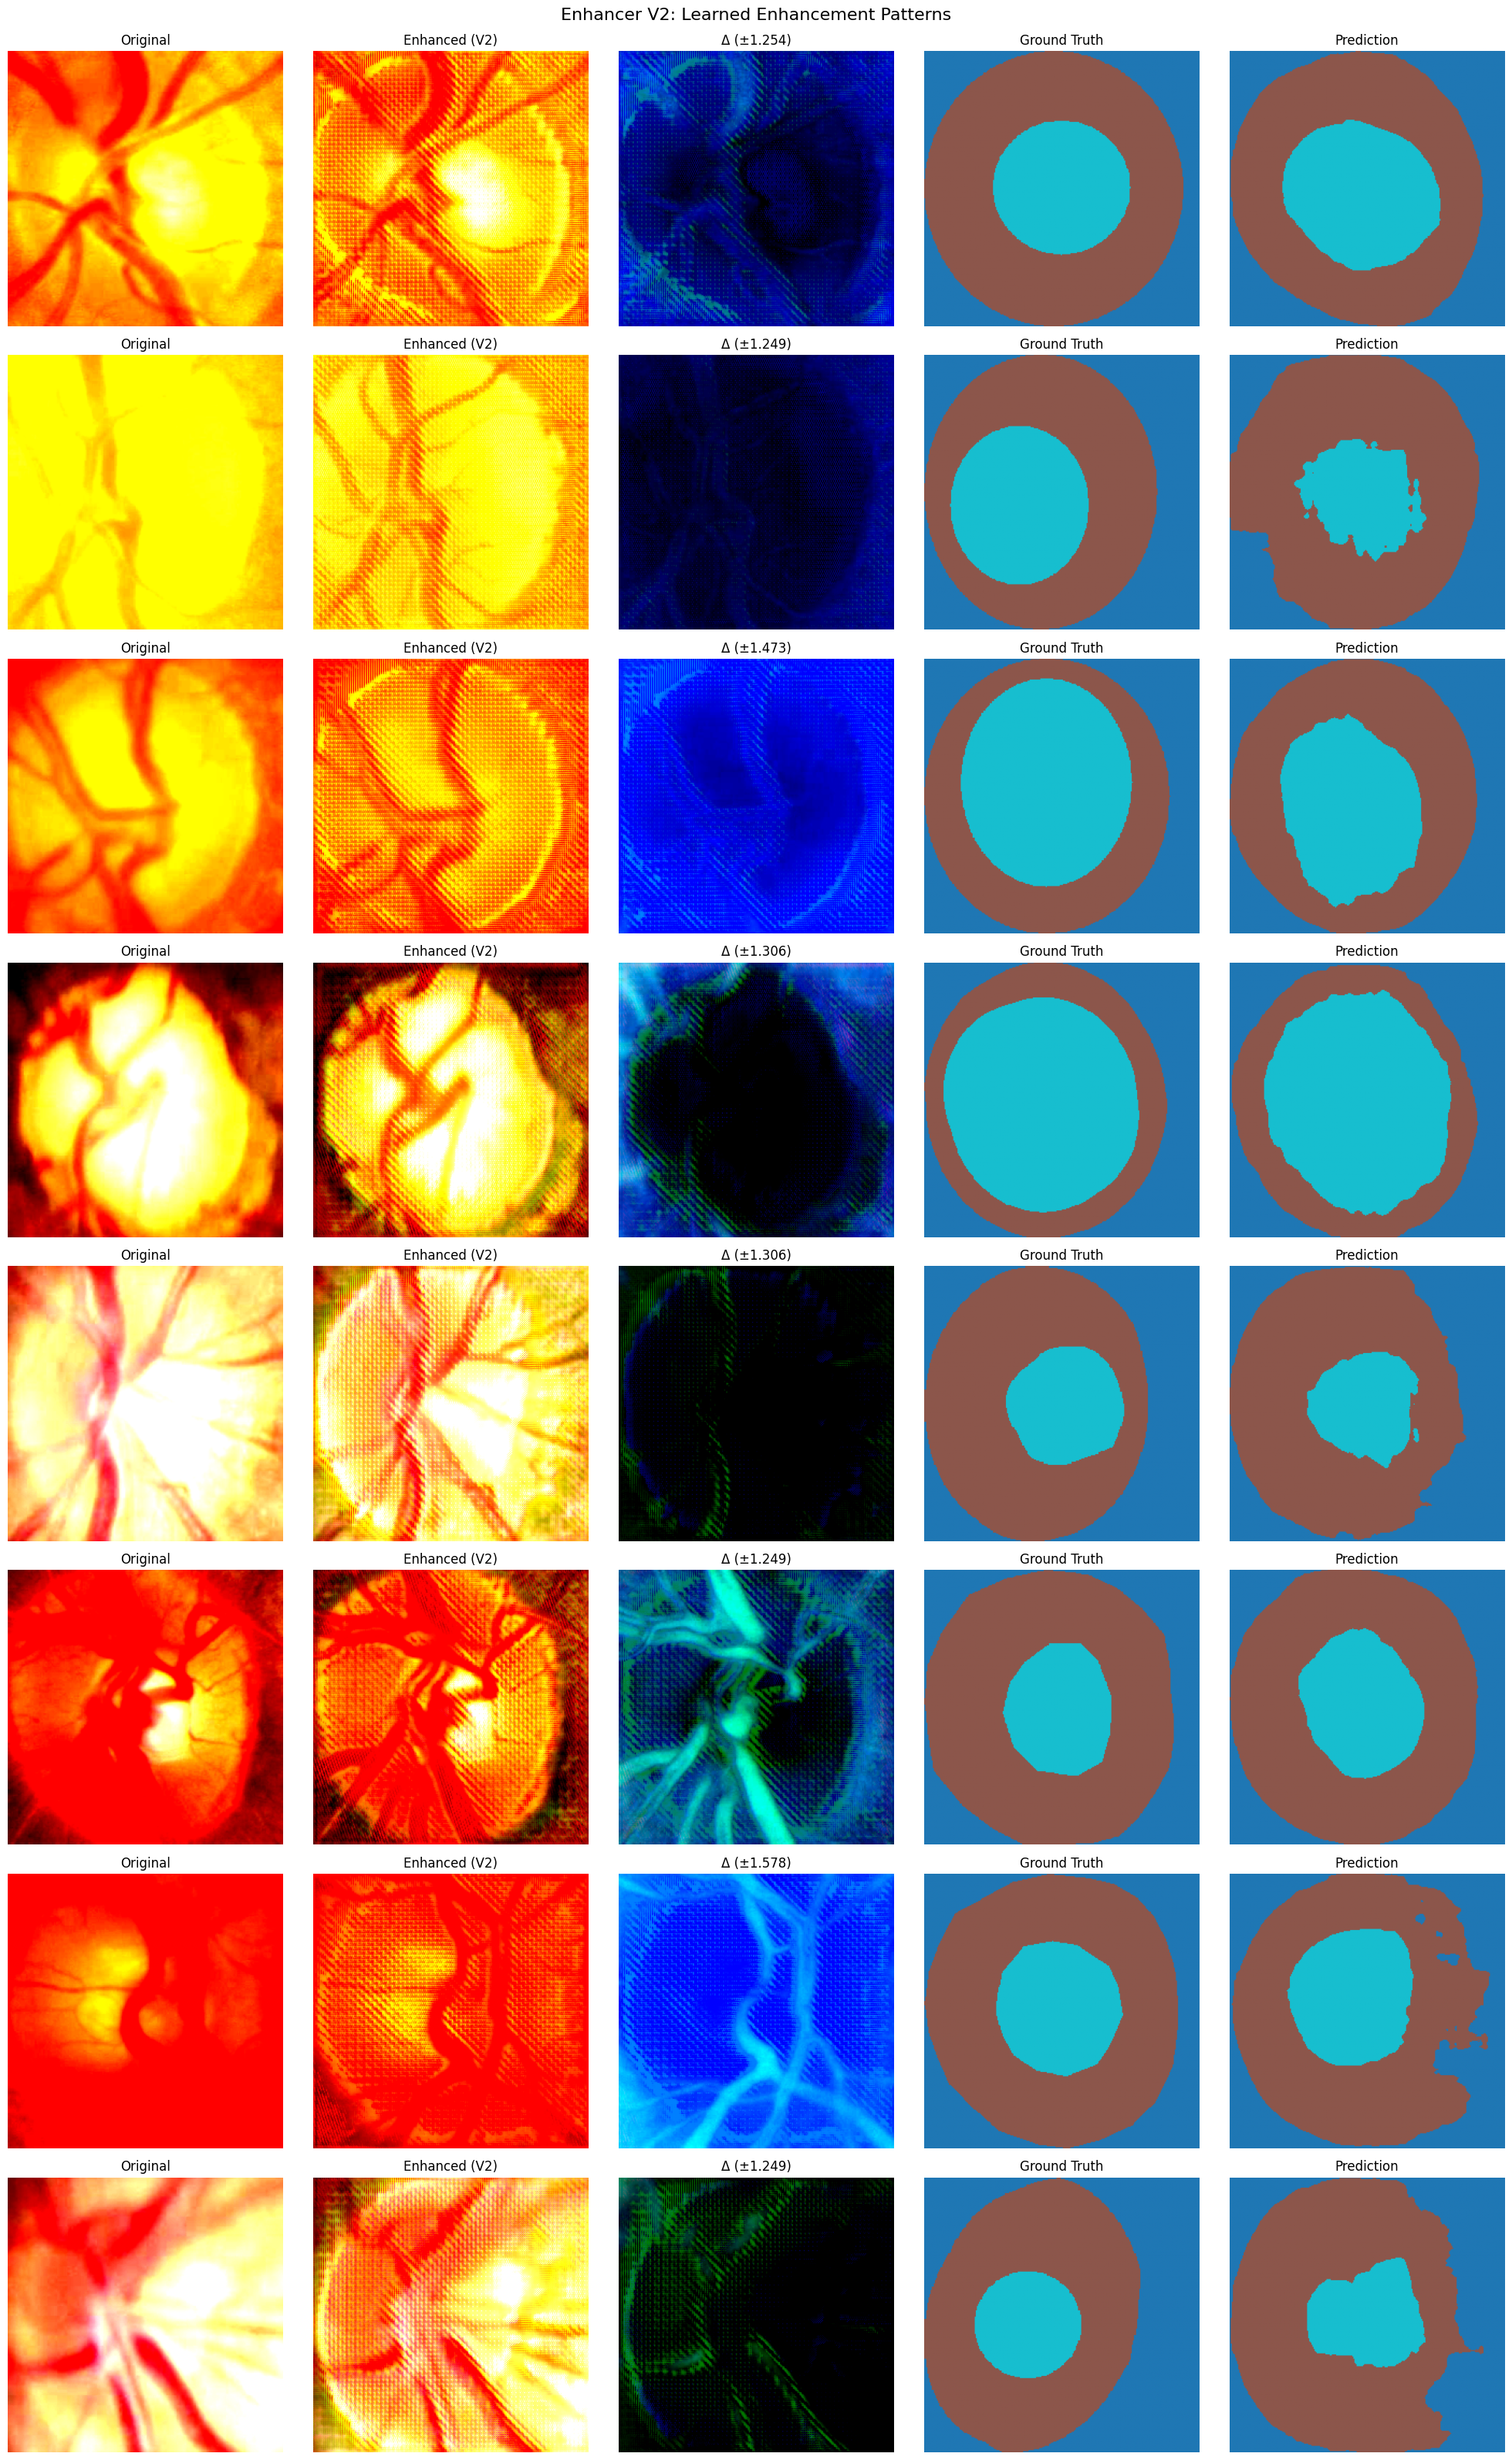


Note: In the difference images:
  - Red: Regions that were darkened
  - Blue: Regions that were brightened
  - White: No change


In [13]:
# Get sample images
sample_images, sample_masks = next(iter(val_loader))
sample_images = sample_images[:8].to(device)
sample_masks = sample_masks[:8].to(device)

# Generate enhancements
with torch.no_grad():
    seg_output, enhanced_images = pipeline_v2(sample_images, return_enhanced=True)
    seg_preds = torch.argmax(seg_output, dim=1)

# Visualize
fig, axes = plt.subplots(8, 5, figsize=(20, 32))

for i in range(8):
    # Original
    img = sample_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')
    
    # Enhanced
    enh = enhanced_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i, 1].imshow(enh)
    axes[i, 1].set_title('Enhanced (V2)')
    axes[i, 1].axis('off')
    
    # Difference (centered at 0, red=darkening, blue=brightening)
    diff = (enh - img)
    abs_max = max(abs(diff.min()), abs(diff.max()))
    axes[i, 2].imshow(diff, cmap='RdBu_r', vmin=-abs_max, vmax=abs_max)
    axes[i, 2].set_title(f'Δ (±{abs_max:.3f})')
    axes[i, 2].axis('off')
    
    # Ground truth
    gt = sample_masks[i].cpu().numpy()
    axes[i, 3].imshow(gt, cmap='tab10', vmin=0, vmax=2)
    axes[i, 3].set_title('Ground Truth')
    axes[i, 3].axis('off')
    
    # Prediction
    pred = seg_preds[i].cpu().numpy()
    axes[i, 4].imshow(pred, cmap='tab10', vmin=0, vmax=2)
    axes[i, 4].set_title('Prediction')
    axes[i, 4].axis('off')

plt.suptitle('Enhancer V2: Learned Enhancement Patterns', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("\nNote: In the difference images:")
print("  - Red: Regions that were darkened")
print("  - Blue: Regions that were brightened")
print("  - White: No change")

## 5. Test Set Evaluation

Now let's evaluate on the test set and compare with all baselines.

In [14]:
def calculate_iou(pred, target, num_classes=3):
    """Calculate IoU for each class."""
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)
        intersection = (pred_cls & target_cls).sum()
        union = (pred_cls | target_cls).sum()
        iou = intersection / (union + 1e-8)
        ious.append(iou)
    return ious

def evaluate_model(model, test_loader, device, is_pipeline=False):
    """Evaluate model on test set."""
    model.eval()
    all_ious = []
    
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Evaluating"):
            images = images.to(device)
            masks = masks.to(device)
            
            if is_pipeline:
                outputs, _ = model(images, return_enhanced=True)
            else:
                outputs = model(images)
            
            preds = torch.argmax(outputs, dim=1)
            
            for pred, mask in zip(preds, masks):
                iou = calculate_iou(pred.cpu().numpy(), mask.cpu().numpy())
                all_ious.append(iou)
    
    all_ious = np.array(all_ious)
    mean_ious = all_ious.mean(axis=0)
    return mean_ious

# Load test data (note: get_dataloaders uses transform_val for test set)
_, _, test_loader = get_dataloaders(
    root_dir=str(root_dir),
    batch_size=16,
    num_workers=4,
    transform_val=get_validation_transforms(image_size=256),  # Fixed: use transform_val instead of transform_test
    filter_incomplete=True
)

print(f"Test set size: {len(test_loader.dataset)} images")

TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples
Test set size: 396 images


In [15]:
# Load baseline model
baseline_model = UNet(n_channels=3, n_classes=3).to(device)
baseline_checkpoint = torch.load(
    root_dir / 'checkpoints' / 'best_model.pth',
    weights_only=False
)
baseline_model.load_state_dict(baseline_checkpoint['model_state_dict'])

# Load CLAHE model
clahe_model = UNet(n_channels=3, n_classes=3).to(device)
clahe_checkpoint = torch.load(
    root_dir / 'checkpoints_clahe' / 'best_model.pth',
    weights_only=False
)
clahe_model.load_state_dict(clahe_checkpoint['model_state_dict'])

print("Models loaded successfully!")

Models loaded successfully!


In [16]:
# Evaluate all models
print("Evaluating Baseline model...")
baseline_ious = evaluate_model(baseline_model, test_loader, device, is_pipeline=False)

print("\nEvaluating CLAHE model...")
# Note: CLAHE model expects CLAHE-preprocessed images, but we're feeding raw images
# This is the same issue V1 had!
clahe_ious = evaluate_model(clahe_model, test_loader, device, is_pipeline=False)

print("\nEvaluating Enhancer V2...")
v2_ious = evaluate_model(pipeline_v2, test_loader, device, is_pipeline=True)

print("\n" + "=" * 80)
print("TEST SET RESULTS")
print("=" * 80)
print(f"\n{'Model':<20} {'BG IoU':<12} {'Disc IoU':<12} {'Cup IoU':<12}")
print("-" * 80)
print(f"{'Baseline (raw)':<20} {baseline_ious[0]:.4f}       {baseline_ious[1]:.4f}       {baseline_ious[2]:.4f}")
print(f"{'CLAHE (mismatch)':<20} {clahe_ious[0]:.4f}       {clahe_ious[1]:.4f}       {clahe_ious[2]:.4f}")
print(f"{'Enhancer V2':<20} {v2_ious[0]:.4f}       {v2_ious[1]:.4f}       {v2_ious[2]:.4f}")

print("\n" + "=" * 80)
print("IMPROVEMENT OVER BASELINE (Disc IoU)")
print("=" * 80)
print(f"Baseline:    {baseline_ious[1]:.4f} (reference)")
print(f"CLAHE:       {(clahe_ious[1] - baseline_ious[1])*100:+.2f}%")
print(f"Enhancer V2: {(v2_ious[1] - baseline_ious[1])*100:+.2f}%")

if v2_ious[1] > baseline_ious[1]:
    print(f"\n✅ SUCCESS! V2 beats baseline by {(v2_ious[1] - baseline_ious[1])*100:.2f}%")
elif v2_ious[1] > clahe_ious[1]:
    print(f"\n⚠️  V2 doesn't beat baseline, but beats CLAHE by {(v2_ious[1] - clahe_ious[1])*100:.2f}%")
else:
    print(f"\n❌ V2 still underperforms. Need further fixes.")
    print(f"   Disc IoU deficit: {(v2_ious[1] - baseline_ious[1])*100:.2f}%")

Evaluating Baseline model...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]


Evaluating CLAHE model...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]


Evaluating Enhancer V2...


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]


TEST SET RESULTS

Model                BG IoU       Disc IoU     Cup IoU     
--------------------------------------------------------------------------------
Baseline (raw)       0.8853       0.8461       0.7852
CLAHE (mismatch)     0.8836       0.8421       0.7801
Enhancer V2          0.8531       0.8071       0.7443

IMPROVEMENT OVER BASELINE (Disc IoU)
Baseline:    0.8461 (reference)
CLAHE:       -0.41%
Enhancer V2: -3.91%

❌ V2 still underperforms. Need further fixes.
   Disc IoU deficit: -3.91%


## 6. Summary and Recommendations

In [17]:
print("=" * 80)
print("ENHANCER V2 EVALUATION SUMMARY")
print("=" * 80)

print("\n📊 Training Metrics:")
print(f"  - Best validation Disc IoU: {history_v2['val_iou_disc'][best_epoch]:.4f} (epoch {best_epoch + 1})")
print(f"  - Final validation Disc IoU: {history_v2['val_iou_disc'][-1]:.4f} (epoch 50)")
print(f"  - Still improving: {'Yes' if improving else 'No (plateaued)'}")

print("\n🔍 Enhancement Magnitude:")
print(f"  - Mean absolute change: {mean_diff:.4f}")
print(f"  - V1 vs V2: {((0.6858 - mean_diff) / 0.6858 * 100):.1f}% reduction in over-modification")
if 0.01 <= mean_diff <= 0.2:
    print(f"  - Status: ✅ Appropriate enhancement range")
elif mean_diff < 0.01:
    print(f"  - Status: ⚠️  Too conservative")
else:
    print(f"  - Status: ❌ Still over-modifying")

print("\n🎯 Test Set Performance:")
print(f"  - Baseline Disc IoU: {baseline_ious[1]:.4f}")
print(f"  - V2 Disc IoU: {v2_ious[1]:.4f} ({(v2_ious[1] - baseline_ious[1])*100:+.2f}%)")
print(f"  - V2 vs V1: {(v2_ious[1] - v1_disc_iou)*100:+.2f}% improvement")

print("\n" + "=" * 80)
print("NEXT STEPS")
print("=" * 80)

if v2_ious[1] > baseline_ious[1]:
    print("\n✅ V2 IS SUCCESSFUL! Consider:")
    print("  1. Train longer (80-100 epochs) for more improvement")
    print("  2. Try different perceptual weights (ablation study)")
    print("  3. Prepare final project presentation")
    print("  4. Document learned enhancement patterns")
elif v2_ious[1] > v1_disc_iou:
    print("\n⚠️  V2 improved over V1 but still below baseline:")
    print("  1. Further reduce perceptual weight (try 0.01, 0.02)")
    print("  2. Reduce enhancement scale in enhancer.py (0.5 → 0.1)")
    print("  3. Try SimpleCNNEnhancer architecture")
    print("  4. Train for more epochs (still improving)")
else:
    print("\n❌ V2 still underperforming. Priority fixes:")
    print("  1. Check enhancement magnitude (if > 0.2, reduce scale)")
    print("  2. Verify correct frozen model is being used")
    print("  3. Try removing perceptual loss entirely")
    print("  4. Consider paired-data approach with CLAHE")

print("\n" + "=" * 80)

ENHANCER V2 EVALUATION SUMMARY

📊 Training Metrics:
  - Best validation Disc IoU: 0.8301 (epoch 47)
  - Final validation Disc IoU: 0.8281 (epoch 50)
  - Still improving: Yes

🔍 Enhancement Magnitude:
  - Mean absolute change: 0.6251
  - V1 vs V2: 8.9% reduction in over-modification
  - Status: ❌ Still over-modifying

🎯 Test Set Performance:
  - Baseline Disc IoU: 0.8461
  - V2 Disc IoU: 0.8071 (-3.91%)
  - V2 vs V1: -1.57% improvement

NEXT STEPS

❌ V2 still underperforming. Priority fixes:
  1. Check enhancement magnitude (if > 0.2, reduce scale)
  2. Verify correct frozen model is being used
  3. Try removing perceptual loss entirely
  4. Consider paired-data approach with CLAHE

